# baseline model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
import os
os.getcwd()

'c:\\Users\\ankit\\OneDrive\\Desktop\\admission-accuracy-improvement\\notebooks'

In [3]:
df = pd.read_csv("../data/admission_predict.csv")
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [4]:
df.shape

(500, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [6]:
df.columns = df.columns.str.strip().str.replace(" ", "_")
df.columns

Index(['Serial_No.', 'GRE_Score', 'TOEFL_Score', 'University_Rating', 'SOP',
       'LOR', 'CGPA', 'Research', 'Chance_of_Admit'],
      dtype='object')

In [7]:
df = df.drop(columns=["Serial_No."])

In [8]:
X = df.drop(columns=["Chance_of_Admit"])
y = df["Chance_of_Admit"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((400, 7), (100, 7))

In [10]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [11]:
y_pred = lr_model.predict(X_test)

In [12]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
r2 = r2_score(y_test, y_pred)

rmse, mae, mape, r2

(np.float64(0.0608658804157831),
 0.04272265427705369,
 np.float64(6.857756648317821),
 0.8188432567829629)

In [13]:
print(f"Baseline RMSE : {rmse:.4f}")
print(f"Baseline MAE  : {mae:.4f}")
print(f"Baseline MAPE : {mape:.2f}%")
print(f"Baseline R²   : {r2:.4f}")

Baseline RMSE : 0.0609
Baseline MAE  : 0.0427
Baseline MAPE : 6.86%
Baseline R²   : 0.8188


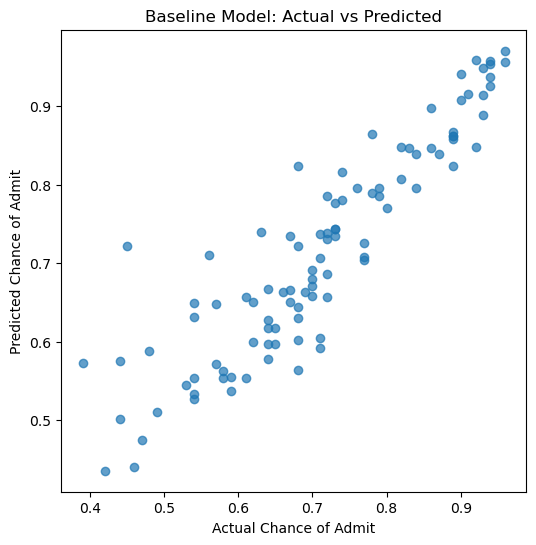

In [14]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Chance of Admit")
plt.ylabel("Predicted Chance of Admit")
plt.title("Baseline Model: Actual vs Predicted")
plt.show()

# feature engineering

In [15]:
from pathlib import Path
import pandas as pd
import numpy as np

In [16]:
df.columns = df.columns.str.strip().str.replace(" ", "_")
df.columns

Index(['GRE_Score', 'TOEFL_Score', 'University_Rating', 'SOP', 'LOR', 'CGPA',
       'Research', 'Chance_of_Admit'],
      dtype='object')

In [17]:
df["GRE_CGPA"] = df["GRE_Score"] * df["CGPA"]
df["TOEFL_CGPA"] = df["TOEFL_Score"] * df["CGPA"]

df[["GRE_CGPA", "TOEFL_CGPA"]].head()

,GRE_CGPA,TOEFL_CGPA
0,3252.05,1138.70
1,2873.88,949.09
2,2528.00,832.00
3,2791.74,953.70
4,2577.94,845.63


In [18]:
df["Academic_Index"] = (
    (df["GRE_Score"] / 340 +
     df["TOEFL_Score"] / 120 +
     df["CGPA"] / 10) / 3
)

df["Academic_Index"].head()

0    0.979837
1    0.910536
2    0.865359
3    0.910242
4    0.867621
Name: Academic_Index, dtype: float64

In [19]:
df["High_CGPA"] = (df["CGPA"] >= 8.5).astype(int)
df["High_GRE"] = (df["GRE_Score"] >= 320).astype(int)

df[["High_CGPA", "High_GRE"]].head()

,High_CGPA,High_GRE
0,1,1
1,1,1
2,0,0
3,1,1
4,0,0


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE_Score          500 non-null    int64  
 1   TOEFL_Score        500 non-null    int64  
 2   University_Rating  500 non-null    int64  
 3   SOP                500 non-null    float64
 4   LOR                500 non-null    float64
 5   CGPA               500 non-null    float64
 6   Research           500 non-null    int64  
 7   Chance_of_Admit    500 non-null    float64
 8   GRE_CGPA           500 non-null    float64
 9   TOEFL_CGPA         500 non-null    float64
 10  Academic_Index     500 non-null    float64
 11  High_CGPA          500 non-null    int64  
 12  High_GRE           500 non-null    int64  
dtypes: float64(7), int64(6)
memory usage: 50.9 KB


In [21]:
df.head()

,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admit,GRE_CGPA,TOEFL_CGPA,Academic_Index,High_CGPA,High_GRE
0,337,118,4,4.5,4.5,9.65,1,0.92,3252.05,1138.70,0.979837,1,1
1,324,107,4,4.0,4.5,8.87,1,0.76,2873.88,949.09,0.910536,1,1
2,316,104,3,3.0,3.5,8.00,1,0.72,2528.00,832.00,0.865359,0,0
3,322,110,3,3.5,2.5,8.67,1,0.80,2791.74,953.70,0.910242,1,1
4,314,103,2,2.0,3.0,8.21,0,0.65,2577.94,845.63,0.867621,0,0


# models

## Objective
Train regularized and tree-based models and compare them
using the same train-test split as the baseline.

In [22]:
from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [23]:
X = df.drop(columns=["Chance_of_Admit"])
y = df["Chance_of_Admit"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
def evaluate(model, X_test, y_test):
    preds = model.predict(X_test)
    
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    
    mape = np.mean(np.abs((y_test - preds) / y_test)) * 100
    r2 = r2_score(y_test, preds)
    
    return rmse, mape, r2

In [33]:
ridge = Ridge()

ridge_params = {
    "alpha": [0.1, 1, 10, 50, 100]
}

ridge_gs = GridSearchCV(
    ridge,
    ridge_params,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

ridge_gs.fit(X_train, y_train)
best_ridge = ridge_gs.best_estimator_
ridge_rmse, ridge_mape, ridge_r2 = evaluate(best_ridge, X_test, y_test)

In [34]:
lasso = Lasso(max_iter=5000)

lasso_params = {
    "alpha": [0.001, 0.01, 0.1, 1]
}

lasso_gs = GridSearchCV(
    lasso,
    lasso_params,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

lasso_gs.fit(X_train, y_train)
best_lasso = lasso_gs.best_estimator_
lasso_rmse, lasso_mape, lasso_r2 = evaluate(best_lasso, X_test, y_test)

In [35]:
rf = RandomForestRegressor(random_state=42)

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20]
}

rf_gs = GridSearchCV(
    rf,
    rf_params,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rf_gs.fit(X_train, y_train)
best_rf = rf_gs.best_estimator_
rf_rmse, rf_mape, rf_r2 = evaluate(best_rf, X_test, y_test)

In [36]:
gb = GradientBoostingRegressor(random_state=42)

gb_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1]
}

gb_gs = GridSearchCV(
    gb,
    gb_params,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

gb_gs.fit(X_train, y_train)
best_gb = gb_gs.best_estimator_
gb_rmse, gb_mape, gb_r2 = evaluate(best_gb, X_test, y_test)

In [37]:
results = pd.DataFrame({
    "Model": ["Ridge", "Lasso", "Random Forest", "Gradient Boosting"],
    "RMSE": [ridge_rmse, lasso_rmse, rf_rmse, gb_rmse],
    "MAPE": [ridge_mape, lasso_mape, rf_mape, gb_mape],
    "R2": [ridge_r2, lasso_r2, rf_r2, gb_r2]
})

results

,Model,RMSE,MAPE,R2
0,Ridge,0.060128,6.756609,0.823207
1,Lasso,0.061136,6.878892,0.817231
2,Random Forest,0.065105,7.071032,0.792732
3,Gradient Boosting,0.065035,7.268123,0.793177


# evaluation comparison
Compare baseline and advanced models and calculate improvement.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

In [41]:
baseline_rmse = 0.0609
new_rmse = 0.060128

In [42]:
improvement = ((baseline_rmse - new_rmse) / baseline_rmse) * 100
improvement

1.2676518883415466

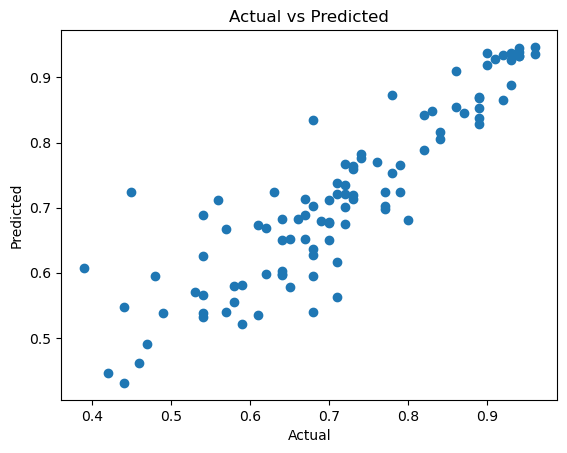

In [43]:
plt.figure()
plt.scatter(y_test, best_gb.predict(X_test))
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

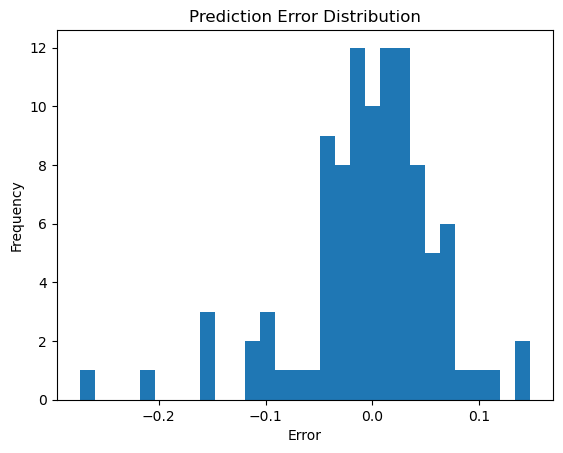

In [44]:
errors = y_test - best_gb.predict(X_test)

plt.figure()
plt.hist(errors, bins=30)
plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()